In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import scienceplots
import matplotlib as mpl
from tqdm import tqdm
#mpl.rcParams.update(mpl.rcParamsDefault)
plt.style.use(['science','notebook'])
plt.rcParams['font.size'] = 18

In [10]:
def compute_gains_and_errors(imbs_X_to_Y, imbs_Y_to_X, correction=True):
    '''imbs_X_to_Y and imbs_Y_to_X have shape (n_seeds, n_taus, n_alphas)
    '''

    assert imbs_X_to_Y.shape == imbs_Y_to_X.shape, "Error: shapes of two inputs do not match!"
    n_indep_realizations = imbs_X_to_Y.shape[0]
    n_taus = imbs_X_to_Y.shape[1]
    
    gain_X_to_Y_indep = 100*(imbs_X_to_Y[:,:,0,np.newaxis]-imbs_X_to_Y[:,:,:]) \
                                    / imbs_X_to_Y[:,:,0,np.newaxis]
    gain_Y_to_X_indep = 100*(imbs_Y_to_X[:,:,0,np.newaxis]-imbs_Y_to_X[:,:,:]) \
                                    / imbs_Y_to_X[:,:,0,np.newaxis]

    gain_X_to_Y_avg = gain_X_to_Y_indep.mean(axis=0)
    gain_Y_to_X_avg = gain_Y_to_X_indep.mean(axis=0)        

    alphas_max_X_to_Y = np.argmax(gain_X_to_Y_avg, axis=-1)
    alphas_max_Y_to_X = np.argmax(gain_Y_to_X_avg, axis=-1)

    gain_X_to_Y_avg = gain_X_to_Y_avg[np.arange(n_taus),alphas_max_X_to_Y]
    gain_Y_to_X_avg = gain_Y_to_X_avg[np.arange(n_taus),alphas_max_Y_to_X] 

    error_X_to_Y = gain_X_to_Y_indep.std(axis=0)[np.arange(n_taus),alphas_max_X_to_Y] \
                    / np.sqrt(n_indep_realizations)
    error_Y_to_X = gain_Y_to_X_indep.std(axis=0)[np.arange(n_taus),alphas_max_Y_to_X] \
                    / np.sqrt(n_indep_realizations)
    
    if correction:
        imb_X_to_Y_avg_alpha0 = imbs_X_to_Y.mean(axis=0)[:,0]
        taus_correction_X_to_Y = np.where(imb_X_to_Y_avg_alpha0 > 1.)
        gain_X_to_Y_avg[taus_correction_X_to_Y] = 0.
        error_X_to_Y[taus_correction_X_to_Y] = 0.
        
        imb_Y_to_X_avg_alpha0 = imbs_Y_to_X.mean(axis=0)[:,0]
        taus_correction_Y_to_X = np.where(imb_Y_to_X_avg_alpha0 > 1.)
        gain_Y_to_X_avg[taus_correction_Y_to_X] = 0.
        error_Y_to_X[taus_correction_Y_to_X] = 0.

    return gain_X_to_Y_avg, gain_Y_to_X_avg, error_X_to_Y, error_Y_to_X, alphas_max_X_to_Y, alphas_max_Y_to_X


def compute_Z_scores(values, errors):
    Z_score =+ np.zeros(len(values))
    for i, _ in enumerate(values):
        if values[i] != 0: Z_score[i] = values[i] / errors[i]
    return Z_score

In [ ]:
plt.rcParams['font.size'] = 18

colors = ["#FF595E","#8AC926","#1982C4","black"]


In [18]:
def make_plot(info_imbalances_X_to_Y, info_imbalances_Y_to_X, label_X_to_Y, label_Y_to_X, xlim=15):

    final_time = 50 # in ps
    final_time_index = final_time * 100 // 20
    taus_plot = taus[:final_time_index]

    (gain_X_to_Y_avg, gain_Y_to_X_avg, error_X_to_Y, 
    error_Y_to_X, alphas_X_to_Y, alphas_Y_to_X) = (
        compute_gains_and_errors(info_imbalances_X_to_Y[:,:final_time_index], 
                                info_imbalances_Y_to_X[:,:final_time_index], correction=True))

    Z_scores_X_to_Y = compute_Z_scores(gain_X_to_Y_avg, error_X_to_Y)
    Z_scores_Y_to_X = compute_Z_scores(gain_Y_to_X_avg, error_Y_to_X)
    #mask_significance_X_to_Y = Z_scores_X_to_Y # > T_stat_99p
    #mask_significance_Y_to_X = Z_scores_Y_to_X # > T_stat_99p

    # plots#
    plt.rcParams['font.size'] = 18
    plt.figure(figsize=(14,5)) 

    plt.plot(taus_plot/100, gain_X_to_Y_avg, '-', label=label_X_to_Y, 
            alpha=0.5, linewidth=2, color=colors[0])
    plt.plot(taus_plot/100, gain_Y_to_X_avg, '-', label=label_Y_to_X,
            alpha=0.5, linewidth=2, color=colors[1])

    #plt.plot(taus_plot[mask_significance_X_to_Y]/100, gain_X_to_Y_avg[mask_significance_X_to_Y], 
    #        'o', color=colors[0], markersize=5)
    #plt.plot(taus_plot[mask_significance_Y_to_X]/100, gain_Y_to_X_avg[mask_significance_Y_to_X], 
    #        's', color=colors[1], markersize=4)

    plt.fill_between(taus_plot/100, gain_X_to_Y_avg - error_X_to_Y, 
                                    gain_X_to_Y_avg + error_X_to_Y, alpha=0.2, color=colors[0])
    plt.fill_between(taus_plot/100, gain_Y_to_X_avg - error_Y_to_X, 
                                    gain_Y_to_X_avg + error_Y_to_X, alpha=0.2, color=colors[1])

    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e/100:.2f}$ ps, $k = {k}$")
    plt.xlabel("$\\tau$ [ps]")
    plt.ylabel("Imbalance Gain [%]")
    plt.xlim([-0.5, xlim])
    #plt.savefig("fig_IG_vs_tau_causality.pdf", dpi=300, bbox_inches="tight")
    plt.show()

    plt.figure(figsize=(14,5))
    plt.hist(alphas_X_to_Y, bins=100, label=label_X_to_Y, alpha=0.5, color=colors[0])
    plt.hist(alphas_Y_to_X, bins=100, label=label_Y_to_X, alpha=0.5, color=colors[1])
    plt.legend() #loc='center left', bbox_to_anchor=(1, 0.5))
    plt.title(f"$E = {E}$, $\\tau_e = {tau_e/100:.2f}$ ps, $k = {k}$")
    plt.xlabel("$\\alpha$")
    plt.ylabel("Frequency")
    plt.show()

In [ ]:
# read files dipole <-> environment, forward time
k = 20
taus = np.arange(0,4920+20,20) #np.arange(0,4440+20,20)
seeds = np.arange(2,3+1)
trajs = np.arange(1,2000+1)
E = 1
tau_e = 1

info_imbalances_ref_to_1st = np.zeros((len(seeds),len(taus),150))
info_imbalances_1st_to_ref = np.zeros((len(seeds),len(taus),150))
#info_imbalances_ref_to_2nd = np.zeros((len(seeds),len(taus),150))
#info_imbalances_2nd_to_ref = np.zeros((len(seeds),len(taus),150))
#info_imbalances_1st_to_2nd = np.zeros((len(seeds),len(taus),150))
#info_imbalances_2nd_to_1st = np.zeros((len(seeds),len(taus),150))

for i, seed in enumerate(seeds):
    for j, tau in enumerate(taus):

        (info_imbalances_ref_to_1st[i,j], info_imbalances_1st_to_ref[i,j], 
        #info_imbalances_ref_to_2nd[i,j], info_imbalances_2nd_to_ref[i,j],
        #info_imbalances_1st_to_2nd[i,j], info_imbalances_2nd_to_1st[i,j]
        ) = (
            pickle.load(open(f"pickles_imb/imb_seed{seed}_tau{tau}_k{k}.p","rb"))
        )

### ref dipole vs 1st shell

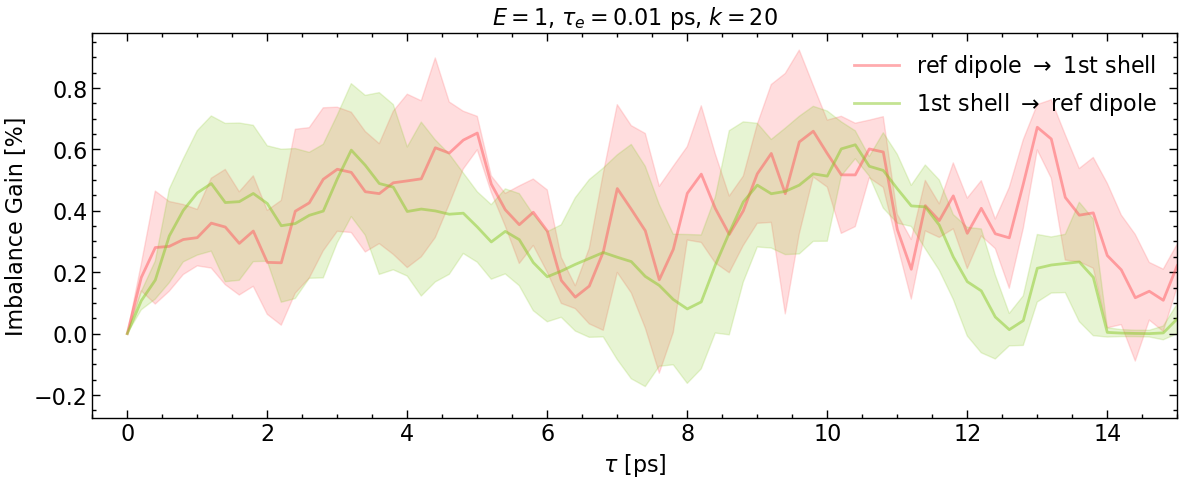

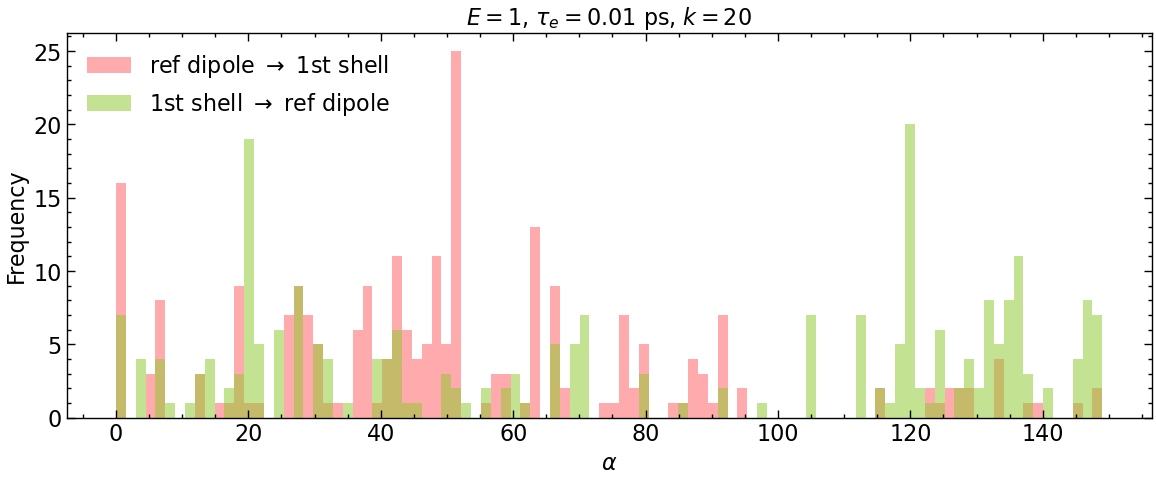

In [20]:
label_xy = "ref dipole $\\rightarrow$ 1st shell"
label_yx = "1st shell $\\rightarrow$ ref dipole"

make_plot(info_imbalances_ref_to_1st, info_imbalances_1st_to_ref, label_xy, label_yx)